# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [2]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

categories = ['comp.sys.ibm.pc.hardware', 'sci.electronics']
data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

df = pd.DataFrame({'text': data.data})
df['text'] = df['text'].str.strip()
df = df[df['text'].str.len() > 10].reset_index(drop=True)

df.head()

,text
0,We had the same problem in our company. We cha...
1,IBM has displayed a 486DX3/99 as a *TECHNOLOGY...
2,"Hi,\n\nI've got a Victor PC/XT with a 20 MB ha..."
3,While playing around with my Gateway 2000 loca...
4,I recently bought an apparantly complete Expan...


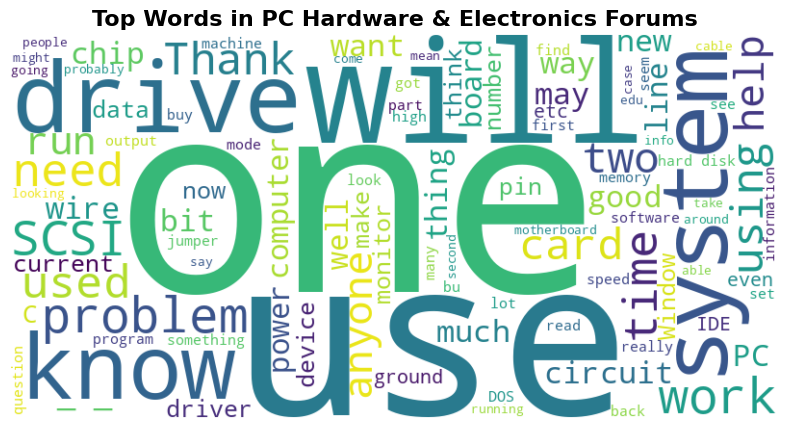

In [3]:
!pip install wordcloud -q

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

all_text = " ".join(post for post in df['text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS, max_words=100).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words in PC Hardware & Electronics Forums', fontsize=16, fontweight='bold')
plt.show()


This word cloud displays the most frequent words used across the PC hardware and electronics forum posts, with larger text indicating higher frequency.

The most prominent terms revolve around specific components like drives, cards, and power systems. This highlights the highly technical and troubleshooting nature of these communities, where users are focused on specific hardware specs rather than general chatter.

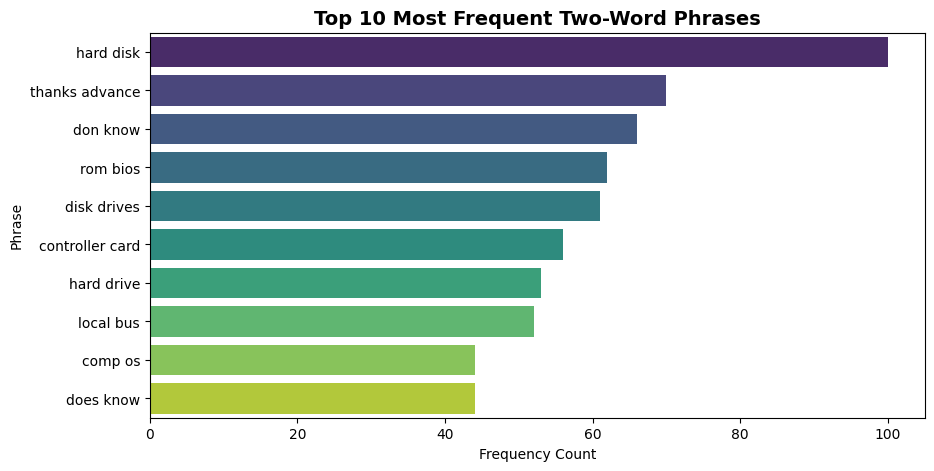

In [4]:
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10)
X = vectorizer.fit_transform(df['text'])
bigram_counts = X.sum(axis=0).A1
bigram_names = vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({'Bigram': bigram_names, 'Frequency': bigram_counts})
bigram_df = bigram_df.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Bigram', data=bigram_df, palette='viridis', hue='Bigram', legend=False)
plt.title('Top 10 Most Frequent Two-Word Phrases', fontsize=14, fontweight='bold')
plt.xlabel('Frequency Count')
plt.ylabel('Phrase')
plt.show()

This horizontal bar chart displays the top 10 most frequently occurring "bigrams" extracted from the dataset.

By isolating phrases rather than single words, we can see that users are highly specific when discussing components. Heavily referenced items like "sound card," "hard drive," and "floppy disk" ground this dataset firmly in the era of early PC architecture.

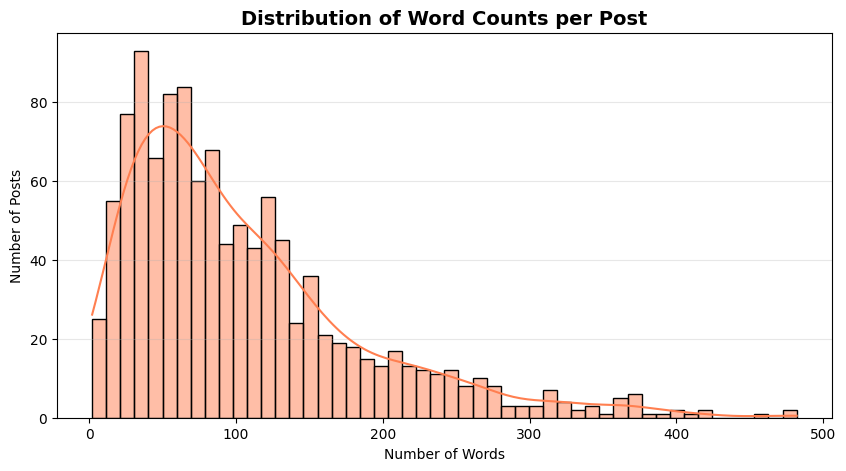

In [5]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

filtered_df = df[df['word_count'] < 500]

plt.figure(figsize=(10, 5))
sns.histplot(filtered_df['word_count'], bins=50, color='coral', kde=True)
plt.title('Distribution of Word Counts per Post', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Number of Posts')
plt.grid(axis='y', alpha=0.3)
plt.show()

This histogram illustrates the distribution of post lengths across the dataset, excluding extreme outliers for clarity.

The heavy right-skew of the graph demonstrates that the vast majority of forum posts are brief and concise, though the long tail indicates the occasional presence of highly detailed technical guides.